In [2]:
# --- Import necessary libraries ---
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from sklearn.model_selection import train_test_split

In [3]:
!pip install git+https://github.com/jacobgil/pytorch-grad-cam.git

  Cloning https://github.com/jacobgil/pytorch-grad-cam.git to /tmp/pip-req-build-7zpk7te0
  Running command git clone --filter=blob:none --quiet https://github.com/jacobgil/pytorch-grad-cam.git /tmp/pip-req-build-7zpk7te0
  Resolved https://github.com/jacobgil/pytorch-grad-cam.git to commit 781dbc0d16ffa95b6d18b96b7b829840a82d93d1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [4]:
# For XAI
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [5]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [6]:
# Enable GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:
# --- Data Preparation ---
class FewShotDataset(Dataset):
    def __init__(self, data_dir, n_way=8, k_shot=5, query_shots=5, 
                 transform=None, mode='train', num_episodes=50, test_size=0.2):
        self.data_dir = data_dir
        self.n_way = n_way
        self.k_shot = k_shot
        self.query_shots = query_shots
        self.transform = transform
        self.mode = mode
        self.num_episodes = num_episodes
        self.test_size = test_size
        
        # Get all class directories
        self.classes = sorted([d for d in os.listdir(data_dir) 
                              if os.path.isdir(os.path.join(data_dir, d))])
        
        if len(self.classes) != 8:
            print(f"Warning: Expected 8 classes, found {len(self.classes)}")
        
        # Split classes into train and test (all classes used in both)
        self.train_classes = self.classes
        self.test_classes = self.classes
        
        # Load and split image paths for each class
        self.class_images = {}
        self.train_images = {}
        self.test_images = {}
        
        for class_name in self.classes:
            class_path = os.path.join(data_dir, class_name)
            images = [os.path.join(class_path, img) for img in os.listdir(class_path) 
                     if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if len(images) < (k_shot + query_shots):
                print(f"Warning: Class {class_name} has only {len(images)} images, "
                      f"but need at least {k_shot + query_shots}")
            
            # Split images into train and test sets
            train_imgs, test_imgs = train_test_split(
                images, test_size=test_size, random_state=42
            )
            
            self.class_images[class_name] = images
            self.train_images[class_name] = train_imgs
            self.test_images[class_name] = test_imgs
        
        # Create episodes
        self.episodes = self._create_episodes()
    
    def _create_episodes(self):
        """Create few-shot learning episodes"""
        episodes = []
        
        for _ in range(self.num_episodes):
            # Use all 8 classes (since n_way=8)
            selected_classes = self.classes  # Use all 8 classes
            episode = {'classes': selected_classes, 'support': [], 'query': []}
            
            for class_idx, class_name in enumerate(selected_classes):
                # Get the appropriate image set based on mode
                if self.mode == 'train':
                    available_images = self.train_images[class_name]
                else:
                    available_images = self.test_images[class_name]
                
                # Ensure we have enough images
                if len(available_images) < (self.k_shot + self.query_shots):
                    print(f"Warning: Not enough images in {class_name} for {self.mode} mode")
                    continue
                
                # Randomly select K support + query samples
                selected_images = random.sample(available_images, self.k_shot + self.query_shots)
                
                # Add to support set
                for img_path in selected_images[:self.k_shot]:
                    episode['support'].append((img_path, class_idx))
                
                # Add to query set
                for img_path in selected_images[self.k_shot:]:
                    episode['query'].append((img_path, class_idx))
            
            # Only add episode if we have enough samples for all classes
            if len(episode['support']) == self.n_way * self.k_shot:
                # Shuffle support and query sets
                random.shuffle(episode['support'])
                random.shuffle(episode['query'])
                episodes.append(episode)
        
        return episodes
    
    def __len__(self):
        return len(self.episodes)
    
    def __getitem__(self, idx):
        """Get a complete episode (support + query sets)"""
        episode = self.episodes[idx]
        
        # Load support set
        support_images, support_labels = [], []
        for img_path, label in episode['support']:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            support_images.append(img)
            support_labels.append(label)
        
        # Load query set
        query_images, query_labels = [], []
        for img_path, label in episode['query']:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            query_images.append(img)
            query_labels.append(label)
        
        return (torch.stack(support_images), torch.tensor(support_labels),
                torch.stack(query_images), torch.tensor(query_labels))

In [18]:
# --- Enhanced Prototypical Network Model with XAI Support (FIXED) ---
class EnhancedPrototypicalNetwork(nn.Module):
    def __init__(self, feature_dim=256, use_pretrained=True):
        super(EnhancedPrototypicalNetwork, self).__init__()
        
        # Use efficientnet_b0 as backbone
        self.backbone = efficientnet_b0(pretrained=use_pretrained)
        
        # Remove the final classification layer but keep more layers for feature extraction
        self.feature_extractor = nn.Sequential(
            *list(self.backbone.children())[:-2]  # Keep more layers for feature extraction
        )
        
        # Add a hook to store the feature maps for Grad-CAM
        self.feature_maps = None
        self.gradients = None
        
        # Register hooks for the last convolutional layer
        self._register_hooks()
        
        # Get the correct output dimension of the modified feature extractor
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            features = self.feature_extractor(dummy_input)
            # Apply adaptive average pooling to get the final feature vector
            features_pooled = F.adaptive_avg_pool2d(features, 1)
            backbone_dim = features_pooled.view(features_pooled.size(0), -1).shape[1]
            print(f"Backbone output dimension: {backbone_dim}")  # Debug print
        
        # Enhanced projection network - using the correct dimension
        self.projection = nn.Sequential(
            nn.Linear(backbone_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
        # Distance metric (Euclidean by default)
        self.distance_metric = 'euclidean'
    
    def _register_hooks(self):
        """Register hooks to capture feature maps and gradients"""
        def forward_hook(module, input, output):
            self.feature_maps = output
            
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]
            
        # Register hooks on the last convolutional layer
        last_conv_layer = None
        for layer in self.feature_extractor.modules():
            if isinstance(layer, nn.Conv2d):
                last_conv_layer = layer
                
        if last_conv_layer is not None:
            last_conv_layer.register_forward_hook(forward_hook)
            last_conv_layer.register_full_backward_hook(backward_hook)
    
    def forward(self, x):
        """Extract features from input images"""
        features = self.feature_extractor(x)
        features = F.adaptive_avg_pool2d(features, 1).view(features.size(0), -1)
        return self.projection(features)
    
    def compute_prototypes(self, support_features, support_labels):
        """Compute class prototypes from support set features"""
        prototypes = []
        unique_labels = torch.unique(support_labels)
        
        for class_label in unique_labels:
            # Get features for this class
            class_mask = (support_labels == class_label)
            class_features = support_features[class_mask]
            # Compute mean prototype
            prototype = class_features.mean(dim=0)
            prototypes.append(prototype)
        
        return torch.stack(prototypes)
    
    def compute_distances(self, query_features, prototypes):
        """Compute distances between query features and prototypes"""
        if self.distance_metric == 'euclidean':
            # Euclidean distance
            distances = torch.cdist(query_features.unsqueeze(0), prototypes.unsqueeze(0))[0]
        elif self.distance_metric == 'cosine':
            # Cosine similarity (convert to distance)
            query_norm = F.normalize(query_features, p=2, dim=1)
            proto_norm = F.normalize(prototypes, p=2, dim=1)
            similarities = torch.mm(query_norm, proto_norm.t())
            distances = 1 - similarities
        else:
            raise ValueError(f"Unknown distance metric: {self.distance_metric}")
        
        return distances
    
    def predict(self, query_features, prototypes):
        """Predict query samples using distance to prototypes"""
        distances = self.compute_distances(query_features, prototypes)
        # Convert distances to probabilities (softmax over negative distances)
        return F.softmax(-distances, dim=1)

In [9]:
# --- XAI Visualization Functions ---
def visualize_prototypes(model, support_imgs, support_labels, class_names, save_path=None):
    """Visualize the prototypes for each class"""
    model.eval()
    with torch.no_grad():
        support_features = model(support_imgs)
        prototypes = model.compute_prototypes(support_features, support_labels)
    
    # Convert prototypes to numpy for visualization
    prototypes_np = prototypes.cpu().numpy()
    
    # Visualize each prototype
    fig, axes = plt.subplots(1, len(prototypes_np), figsize=(15, 5))
    if len(prototypes_np) == 1:
        axes = [axes]
    
    for i, (prototype, ax) in enumerate(zip(prototypes_np, axes)):
        # Reshape and normalize the prototype for visualization
        prototype_img = (prototype - prototype.min()) / (prototype.max() - prototype.min())
        # Reshape to a square if possible
        size = int(np.sqrt(len(prototype_img)))
        if size * size == len(prototype_img):
            prototype_img = prototype_img.reshape(size, size)
        else:
            # Fallback to 1D visualization
            prototype_img = prototype_img.reshape(1, -1)
        
        ax.imshow(prototype_img, cmap='viridis')
        ax.set_title(f'Prototype: {class_names[i]}')
        ax.axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [19]:
# --- Modified XAI functions for the simpler model ---
def generate_grad_cam_simple(model, query_imgs, query_labels, support_imgs, support_labels, class_names, save_dir='/kaggle/working/grad_cam'):
    """Generate Grad-CAM visualizations for query images (simpler version)"""
    model.eval()
    
    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Get support features and prototypes
    with torch.no_grad():
        support_features = model(support_imgs)
        prototypes = model.compute_prototypes(support_features, support_labels)
    
    # Process each query image
    for i, (query_img, label) in enumerate(zip(query_imgs, query_labels)):
        if i >= 3:  # Limit to first 3 images for efficiency
            break
            
        # Prepare input
        input_tensor = query_img.unsqueeze(0).to(device)
        input_tensor.requires_grad = True
        
        # Clear previous feature maps
        model.feature_maps = None
        
        # Forward pass to get feature maps
        with torch.no_grad():
            query_features = model(input_tensor)
            predictions = model.predict(query_features, prototypes)
            _, predicted = torch.max(predictions, 1)
        
        # If we have feature maps, create a simple CAM
        if model.feature_maps is not None:
            # Simple global average pooling of feature maps
            cam = torch.mean(model.feature_maps, dim=1, keepdim=True)
            cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
            cam = cam - cam.min()
            cam = cam / cam.max()
            
            # Convert to numpy
            cam = cam.squeeze().cpu().numpy()
            
            # Convert query image to numpy for visualization
            rgb_img = query_img.permute(1, 2, 0).cpu().numpy()
            # Denormalize the image
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            rgb_img = std * rgb_img + mean
            rgb_img = np.clip(rgb_img, 0, 1)
            
            # Create visualization
            visualization = show_cam_on_image(rgb_img, cam, use_rgb=True)
            
            # Plot
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Original image
            axes[0].imshow(rgb_img)
            axes[0].set_title(f'Original: {class_names[label.item()]}')
            axes[0].axis('off')
            
            # Heatmap
            axes[1].imshow(cam, cmap='jet')
            axes[1].set_title(f'Heatmap (Predicted: {class_names[predicted.item()]})')
            axes[1].axis('off')
            
            # Overlay
            axes[2].imshow(rgb_img)
            axes[2].imshow(cam, cmap='jet', alpha=0.5)
            axes[2].set_title('Overlay')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.savefig(f'{save_dir}/grad_cam_{i}.png', dpi=300, bbox_inches='tight')
            plt.show()

In [20]:
def analyze_feature_importance(model, support_imgs, support_labels, query_imgs, query_labels, class_names, save_path=None):
    """Analyze which features are most important for classification"""
    model.eval()
    with torch.no_grad():
        # Get support features and compute prototypes
        support_features = model(support_imgs)
        prototypes = model.compute_prototypes(support_features, support_labels)
        
        # Get query features
        query_features = model(query_imgs)
        
        # Calculate distances to each prototype
        distances = model.compute_distances(query_features, prototypes)
        
        # Calculate feature importance based on contribution to distance
        feature_importance = torch.abs(query_features - prototypes[query_labels])
        
        # Average importance across all query images
        avg_importance = feature_importance.mean(dim=0).cpu().numpy()
    
    # Visualize feature importance
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(avg_importance)), avg_importance)
    plt.title("Average Feature Importance Across Query Images")
    plt.xlabel("Feature Dimension")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return avg_importance

In [21]:
# --- Training Setup ---
# Data transformations
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [22]:
# Create datasets
data_dir = "/kaggle/input/cucumber-dataset/Original Image"

print("Creating datasets...")
train_dataset = FewShotDataset(
    data_dir=data_dir,
    n_way=8,
    k_shot=5,
    query_shots=5,
    transform=train_transform,
    mode='train',
    num_episodes=100,
    test_size=0.2
)

test_dataset = FewShotDataset(
    data_dir=data_dir,
    n_way=8,
    k_shot=5,
    query_shots=5,
    transform=test_transform,
    mode='test',
    num_episodes=20,
    test_size=0.2
)

print(f"Training episodes: {len(train_dataset)}")
print(f"Test episodes: {len(test_dataset)}")

Creating datasets...
Training episodes: 100
Test episodes: 20


In [23]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)

# --- Training Function ---
def train_model(model, train_loader, val_loader, optimizer, criterion, num_epochs=15):
    """Train the prototypical network with validation"""
    model.train()
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    
    best_val_accuracy = 0.0
    patience_counter = 0
    patience = 5  # Early stopping patience
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        epoch_train_accuracy = 0.0
        num_train_episodes = 0
        
        for support_imgs, support_labels, query_imgs, query_labels in train_loader:
            # Move data to device
            support_imgs = support_imgs.squeeze(0).to(device)
            support_labels = support_labels.squeeze(0).to(device)
            query_imgs = query_imgs.squeeze(0).to(device)
            query_labels = query_labels.squeeze(0).to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Extract features
            support_features = model(support_imgs)
            query_features = model(query_imgs)
            
            # Compute prototypes
            prototypes = model.compute_prototypes(support_features, support_labels)
            
            # Predict query samples
            predictions = model.predict(query_features, prototypes)
            
            # Calculate loss
            loss = criterion(predictions, query_labels)
            
            # Calculate accuracy
            _, predicted = torch.max(predictions, 1)
            accuracy = (predicted == query_labels).float().mean()
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            epoch_train_accuracy += accuracy.item()
            num_train_episodes += 1
        
        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_accuracy = 0.0
        num_val_episodes = 0
        
        with torch.no_grad():
            for support_imgs, support_labels, query_imgs, query_labels in val_loader:
                support_imgs = support_imgs.squeeze(0).to(device)
                support_labels = support_labels.squeeze(0).to(device)
                query_imgs = query_imgs.squeeze(0).to(device)
                query_labels = query_labels.squeeze(0).to(device)
                
                support_features = model(support_imgs)
                query_features = model(query_imgs)
                prototypes = model.compute_prototypes(support_features, support_labels)
                predictions = model.predict(query_features, prototypes)
                
                loss = criterion(predictions, query_labels)
                _, predicted = torch.max(predictions, 1)
                accuracy = (predicted == query_labels).float().mean()
                
                epoch_val_loss += loss.item()
                epoch_val_accuracy += accuracy.item()
                num_val_episodes += 1
        
        # Calculate epoch statistics
        avg_train_loss = epoch_train_loss / num_train_episodes
        avg_train_accuracy = epoch_train_accuracy / num_train_episodes
        avg_val_loss = epoch_val_loss / num_val_episodes
        avg_val_accuracy = epoch_val_accuracy / num_val_episodes
        
        train_losses.append(avg_train_loss)
        train_accuracies.append(avg_train_accuracy)
        val_losses.append(avg_val_loss)
        val_accuracies.append(avg_val_accuracy)
        
        print(f'Epoch [{epoch+1}/{num_epochs}]')
        print(f'Train - Loss: {avg_train_loss:.4f}, Accuracy: {avg_train_accuracy:.4f}')
        print(f'Val   - Loss: {avg_val_loss:.4f}, Accuracy: {avg_val_accuracy:.4f}')
        print('-' * 50)
        
        # Early stopping check
        if avg_val_accuracy > best_val_accuracy:
            best_val_accuracy = avg_val_accuracy
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), '/kaggle/working/best_prototypical_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return train_losses, train_accuracies, val_losses, val_accuracies

In [25]:
# --- Main Training Execution (FIXED) ---
# Initialize model, optimizer, and loss function
print("Initializing model...")
# Use the simpler version that maintains compatibility
model = EnhancedPrototypicalNetwork(feature_dim=256, use_pretrained=True).to(device)

# Use Adam optimizer with weight decay
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3, verbose=True
)

criterion = nn.CrossEntropyLoss()

# Create a validation loader (using 20% of training episodes for validation)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size], 
    generator=torch.Generator().manual_seed(42)
)

train_loader_sub = DataLoader(train_subset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1, shuffle=False)

# Train the model
print("Starting training...")
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    model, train_loader_sub, val_loader, optimizer, criterion, num_epochs=15
)

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_prototypical_model.pth'))
print("Loaded best model for evaluation")

Initializing model...
Backbone output dimension: 1280
Starting training...
Epoch [1/15]
Train - Loss: 1.7637, Accuracy: 0.6344
Val   - Loss: 1.4337, Accuracy: 0.8650
--------------------------------------------------
Epoch [2/15]
Train - Loss: 1.3957, Accuracy: 0.9244
Val   - Loss: 1.3171, Accuracy: 0.9613
--------------------------------------------------
Epoch [3/15]
Train - Loss: 1.3158, Accuracy: 0.9784
Val   - Loss: 1.2956, Accuracy: 0.9788
--------------------------------------------------
Epoch [4/15]
Train - Loss: 1.2980, Accuracy: 0.9853
Val   - Loss: 1.2852, Accuracy: 0.9913
--------------------------------------------------
Epoch [5/15]
Train - Loss: 1.2901, Accuracy: 0.9909
Val   - Loss: 1.2825, Accuracy: 0.9925
--------------------------------------------------
Epoch [6/15]
Train - Loss: 1.2872, Accuracy: 0.9922
Val   - Loss: 1.2814, Accuracy: 0.9938
--------------------------------------------------
Epoch [7/15]
Train - Loss: 1.2849, Accuracy: 0.9934
Val   - Loss: 1.2808,

In [26]:
# --- Comprehensive Evaluation with XAI ---
CUCUMBER_CLASSES = [
    "Anthracnose",  
    "Bacterial Wilt",  
    "Belly Rot",  
    "Downy Mildew",  
    "Fresh Cucumber",  
    "Fresh Leaf",  
    "Gummy Stem Blight",  
    "Pythium Fruit Rot"   
]

In [27]:
# --- Update the comprehensive evaluation to use the simpler Grad-CAM ---
def comprehensive_evaluation_with_xai(model, test_loader, class_names=CUCUMBER_CLASSES):
    """Comprehensive evaluation with XAI integration"""
    model.eval()
    all_accuracies = []
    num_classes = len(class_names)
    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)
    
    # Get one batch for XAI visualization
    support_imgs, support_labels, query_imgs, query_labels = next(iter(test_loader))
    support_imgs = support_imgs.squeeze(0).to(device)
    support_labels = support_labels.squeeze(0).to(device)
    query_imgs = query_imgs.squeeze(0).to(device)
    query_labels = query_labels.squeeze(0).to(device)
    
    with torch.no_grad():
        for i, (support_imgs, support_labels, query_imgs, query_labels) in enumerate(test_loader):
            support_imgs = support_imgs.squeeze(0).to(device)
            support_labels = support_labels.squeeze(0).to(device)
            query_imgs = query_imgs.squeeze(0).to(device)
            query_labels = query_labels.squeeze(0).to(device)
            
            support_features = model(support_imgs)
            query_features = model(query_imgs)
            prototypes = model.compute_prototypes(support_features, support_labels)
            predictions = model.predict(query_features, prototypes)
            
            _, predicted = torch.max(predictions, 1)
            accuracy = (predicted == query_labels).float().mean()
            all_accuracies.append(accuracy.item())
            
            # Update confusion matrix
            for true, pred in zip(query_labels.cpu().numpy(), predicted.cpu().numpy()):
                confusion_matrix[true, pred] += 1
            
            # Only run XAI on the first batch for efficiency
            if i == 0:
                print("Running XAI visualizations...")
                
                # Visualize prototypes
                visualize_prototypes(model, support_imgs, support_labels, class_names, 
                                    '/kaggle/working/prototype_visualization.png')
                
                # Generate simpler Grad-CAM visualizations
                generate_grad_cam_simple(model, query_imgs, query_labels, support_imgs, support_labels, class_names)
                
                # Analyze feature importance
                feature_importance = analyze_feature_importance(
                    model, support_imgs, support_labels, query_imgs, query_labels, class_names,
                    '/kaggle/working/feature_importance.png'
                )
    
    # ... rest of the evaluation code remains the same ...
    # Calculate metrics
    mean_accuracy = np.mean(all_accuracies)
    std_accuracy = np.std(all_accuracies)
    
    # Calculate per-class accuracy
    class_accuracy = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    
    print(f'Overall Test Accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}')
    print('\nPer-class Accuracy:')
    for i, (class_name, acc) in enumerate(zip(class_names, class_accuracy)):
        print(f'  {class_name}: {acc:.4f}')
    
    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    plt.imshow(confusion_matrix, cmap='Blues', interpolation='nearest')
    plt.colorbar()
    
    # Set ticks and labels
    plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
    
    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, confusion_matrix[i, j], 
                    ha='center', va='center', 
                    color='white' if confusion_matrix[i, j] > confusion_matrix.max() / 2 else 'black')
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Cucumber Disease Classification')
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix_with_names.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return all_accuracies, confusion_matrix


Running comprehensive evaluation with XAI...
Running XAI visualizations...


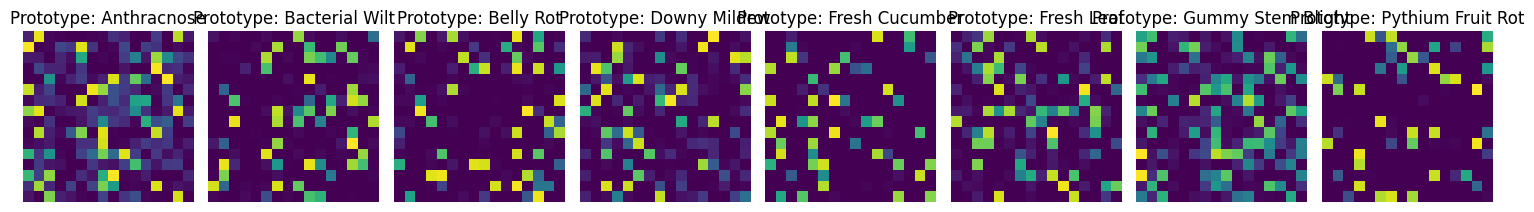

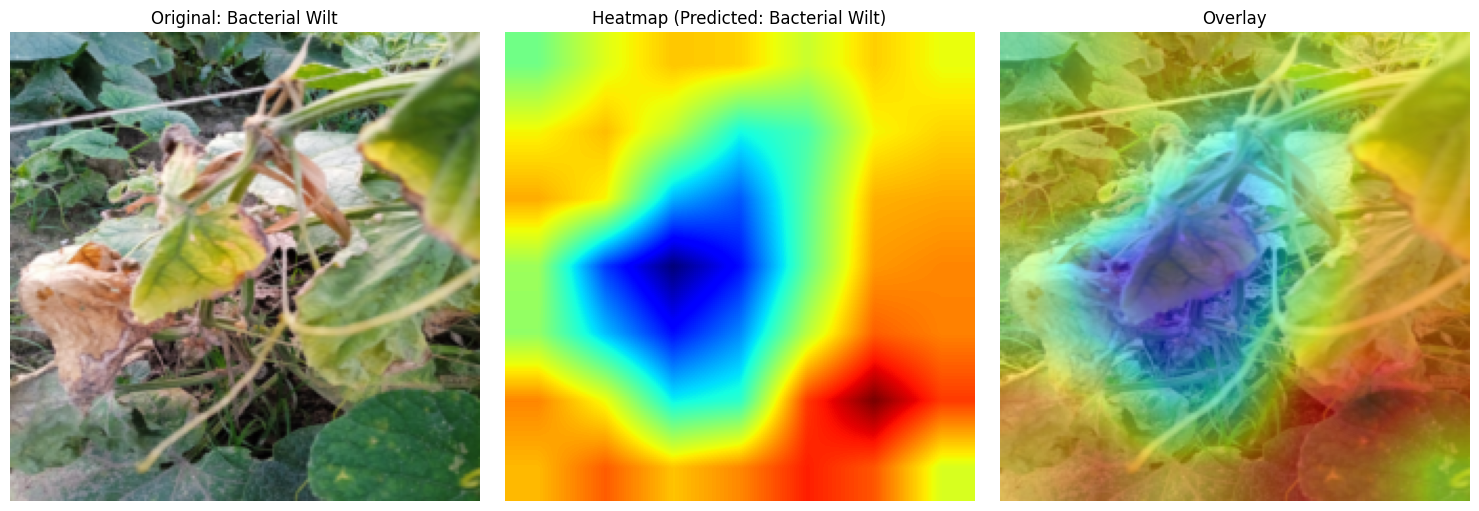

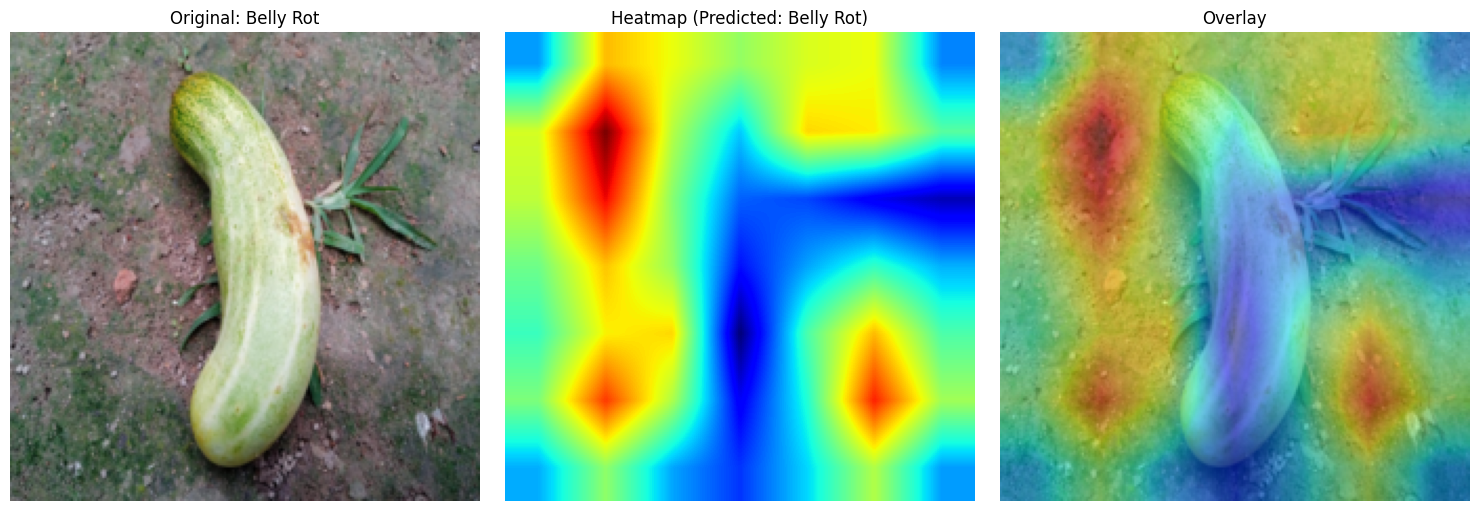

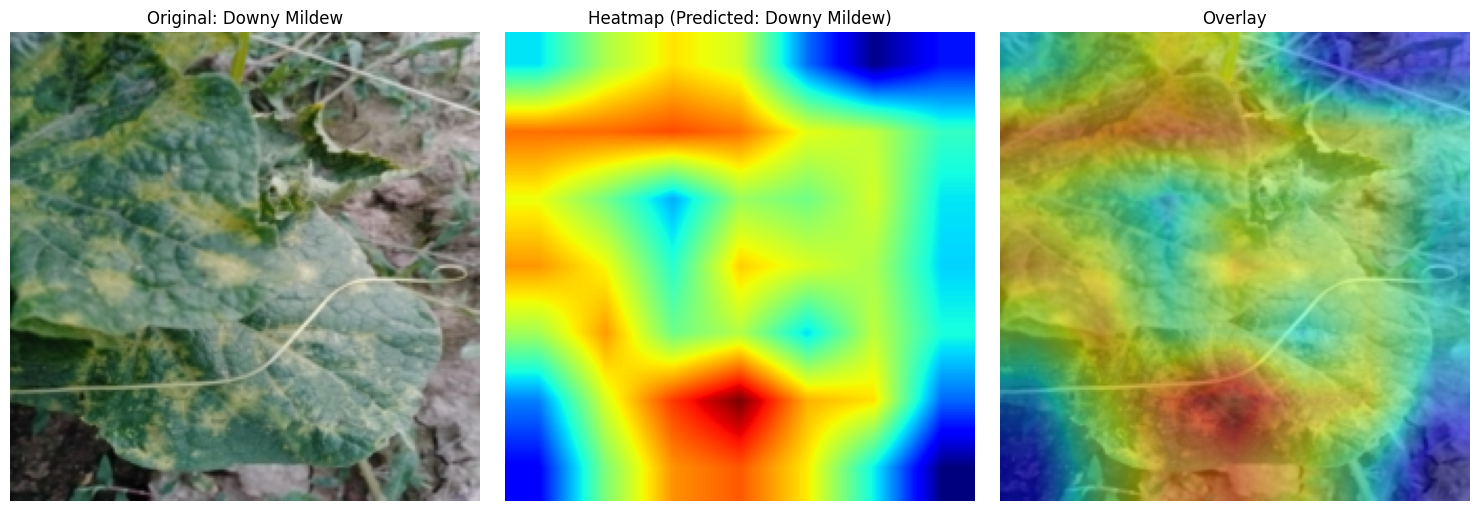

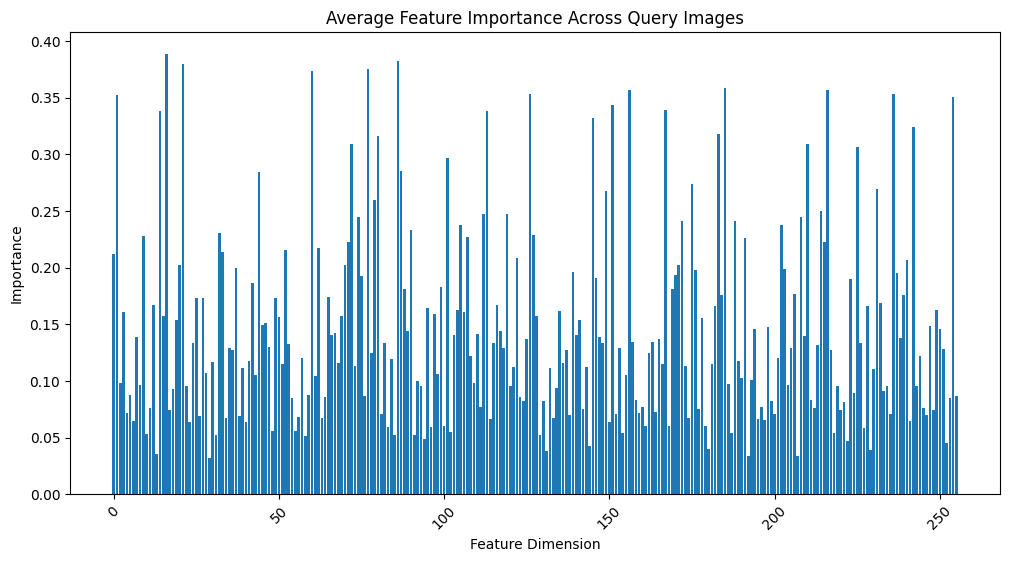

Overall Test Accuracy: 0.9188 ± 0.0467

Per-class Accuracy:
  Anthracnose: 0.7500
  Bacterial Wilt: 1.0000
  Belly Rot: 0.9600
  Downy Mildew: 0.9200
  Fresh Cucumber: 1.0000
  Fresh Leaf: 0.9100
  Gummy Stem Blight: 0.8100
  Pythium Fruit Rot: 1.0000


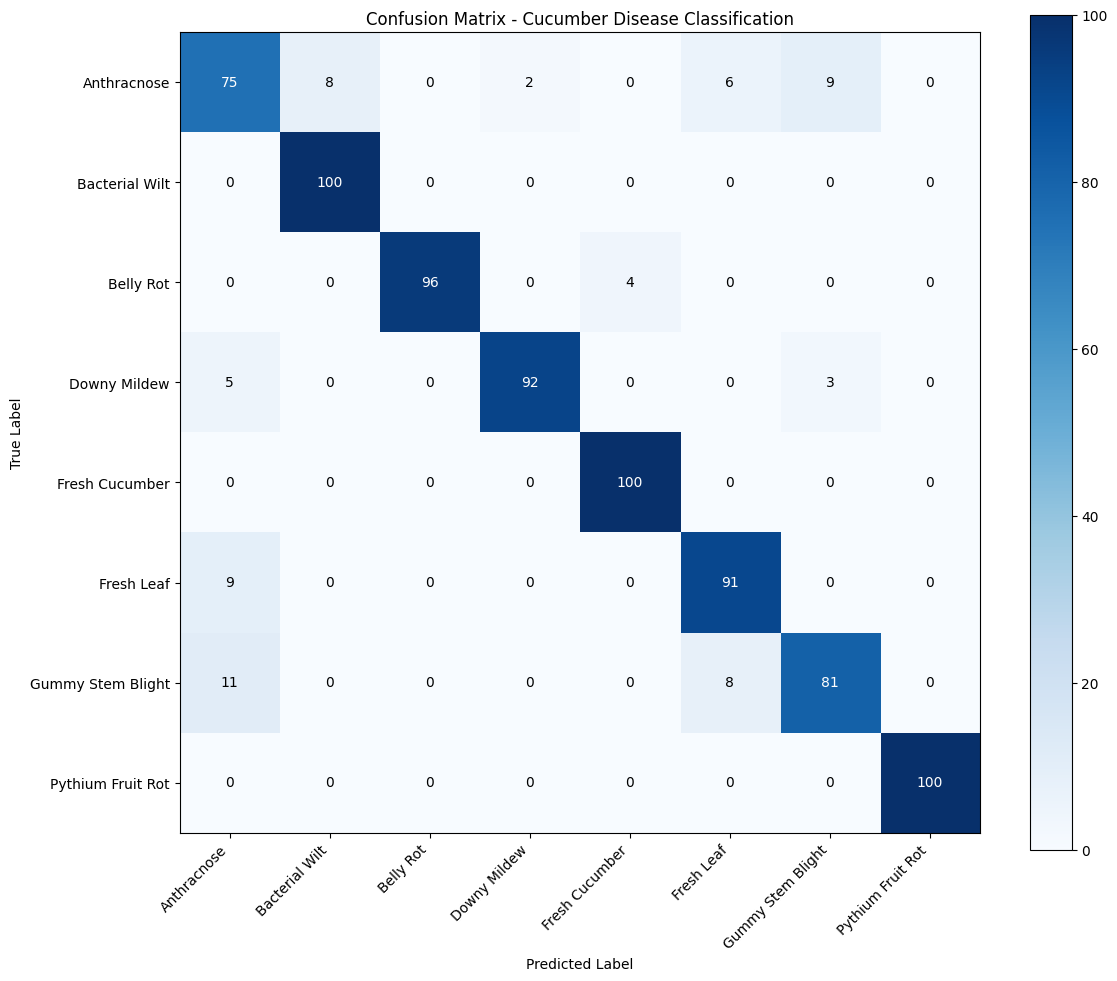

In [28]:
# Run comprehensive evaluation with XAI
print("\nRunning comprehensive evaluation with XAI...")
test_accuracies, confusion_matrix = comprehensive_evaluation_with_xai(model, test_loader, CUCUMBER_CLASSES)


GENERATING COMPREHENSIVE XAI REPORT
COMPREHENSIVE XAI REPORT

1. PROTOTYPE ANALYSIS
--------------------------------------------------

Prototype Similarity Matrix:
Rows/Columns: Anthracnose | Bacterial Wilt | Belly Rot | Downy Mildew | Fresh Cucumber | Fresh Leaf | Gummy Stem Blight | Pythium Fruit Rot
Anthracnose         : 0.000, 12.195, 14.782, 11.481, 15.666, 13.390, 4.226, 15.601
Bacterial Wilt      : 12.195, 0.000, 16.389, 15.269, 17.400, 15.879, 12.213, 16.884
Belly Rot           : 14.782, 16.389, 0.000, 15.987, 16.865, 17.220, 14.412, 17.041
Downy Mildew        : 11.481, 15.269, 15.987, 0.000, 15.721, 15.007, 11.970, 17.019
Fresh Cucumber      : 15.666, 17.400, 16.865, 15.721, 0.000, 18.014, 15.446, 19.023
Fresh Leaf          : 13.390, 15.879, 17.220, 15.007, 18.014, 0.000, 13.418, 18.268
Gummy Stem Blight   : 4.226, 12.213, 14.412, 11.970, 15.446, 13.418, 0.000, 15.015
Pythium Fruit Rot   : 15.601, 16.884, 17.041, 17.019, 19.023, 18.268, 15.015, 0.000

Most Similar Prototype 

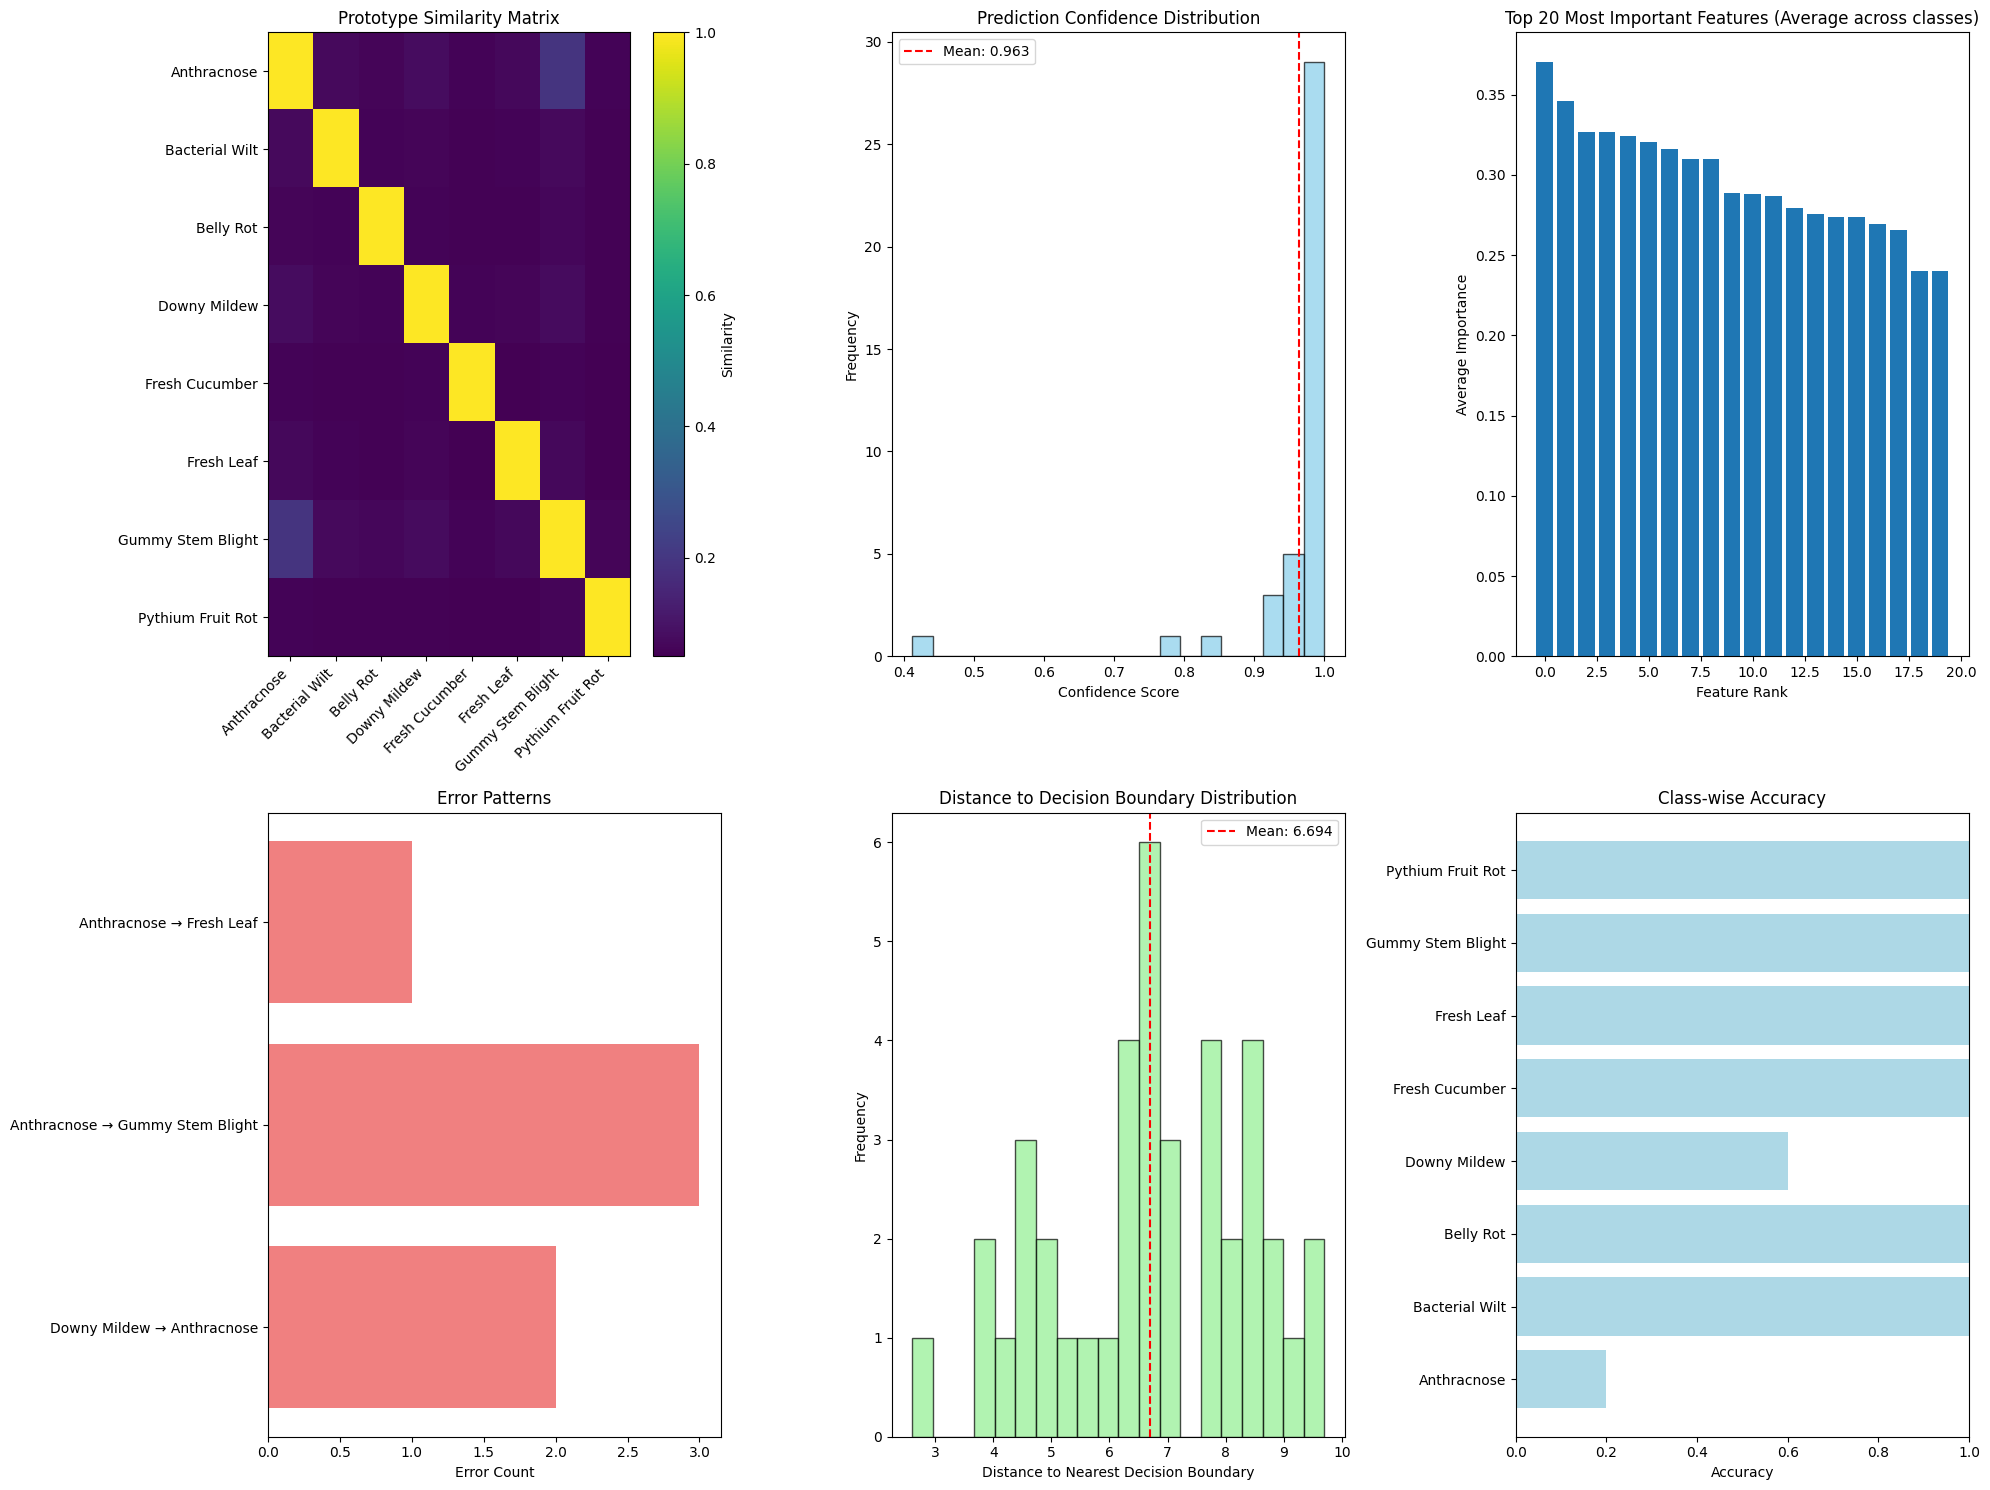


7. MODEL RECOMMENDATIONS
--------------------------------------------------
✓ Good model performance detected!
  - Model is learning meaningful representations
  - Focus on improving low-performing classes

🔍 Focus Area: Most common error is Anthracnose → Gummy Stem Blight
  - Consider adding more diverse examples of these classes
  - Review feature representations for these classes

⚠ High confidence in incorrect predictions detected
  - Model may be overconfident in wrong predictions
  - Consider regularization techniques

XAI REPORT COMPLETE

CREATING DETAILED XAI VISUALIZATIONS

1. Creating t-SNE Visualization...


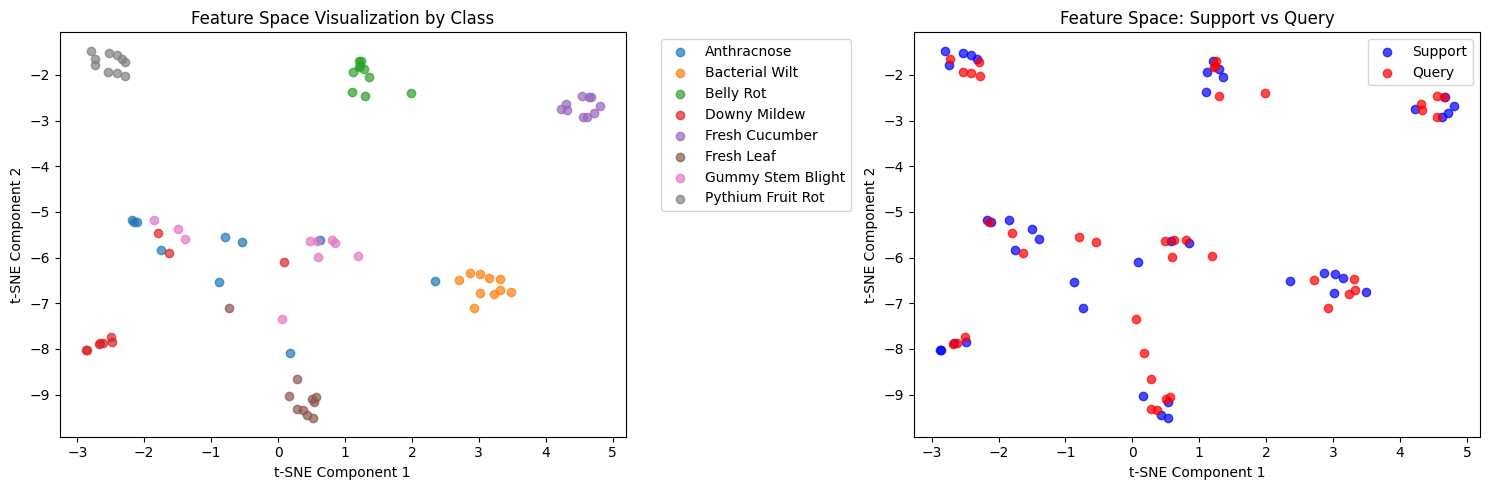

2. Creating Confidence-Calibration Plot...


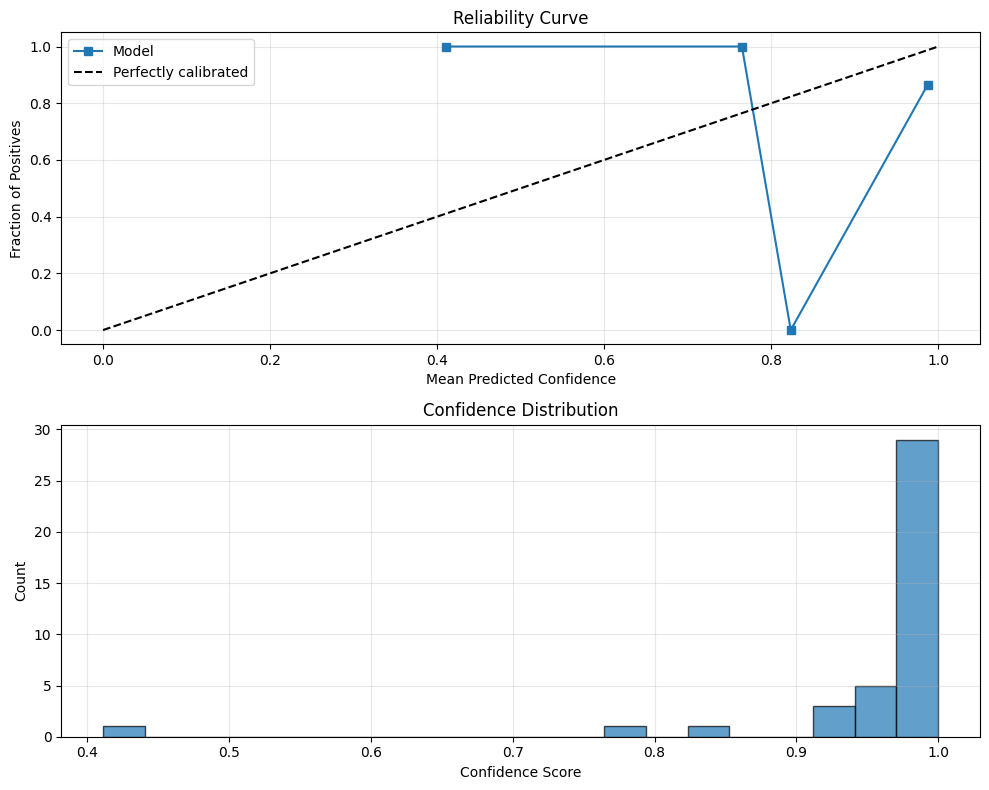

3. Creating Prototype Stability Analysis...


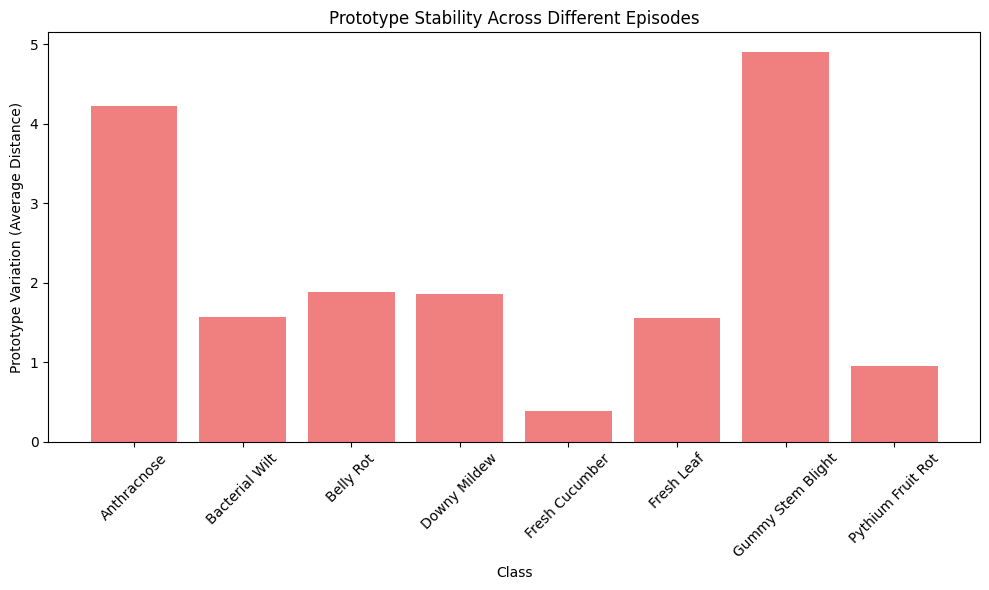


Prototype Stability Scores:
  Anthracnose: 4.2227
  Bacterial Wilt: 1.5653
  Belly Rot: 1.8822
  Downy Mildew: 1.8618
  Fresh Cucumber: 0.3886
  Fresh Leaf: 1.5519
  Gummy Stem Blight: 4.9074
  Pythium Fruit Rot: 0.9523

XAI ANALYSIS COMPLETE!
All visualizations saved to /kaggle/working/


In [29]:
# --- Comprehensive XAI Report ---
def generate_xai_report(model, test_loader, class_names=CUCUMBER_CLASSES):
    """Generate a comprehensive XAI report with multiple visualization techniques"""
    print("=" * 80)
    print("COMPREHENSIVE XAI REPORT")
    print("=" * 80)
    
    model.eval()
    
    # Get a batch for analysis
    support_imgs, support_labels, query_imgs, query_labels = next(iter(test_loader))
    support_imgs = support_imgs.squeeze(0).to(device)
    support_labels = support_labels.squeeze(0).to(device)
    query_imgs = query_imgs.squeeze(0).to(device)
    query_labels = query_labels.squeeze(0).to(device)
    
    with torch.no_grad():
        # Get features and prototypes
        support_features = model(support_imgs)
        query_features = model(query_imgs)
        prototypes = model.compute_prototypes(support_features, support_labels)
        predictions = model.predict(query_features, prototypes)
        _, predicted = torch.max(predictions, 1)
    
    # 1. PROTOTYPE ANALYSIS
    print("\n1. PROTOTYPE ANALYSIS")
    print("-" * 50)
    
    # Calculate prototype distances
    prototype_distances = torch.cdist(prototypes.unsqueeze(0), prototypes.unsqueeze(0))[0]
    
    print("\nPrototype Similarity Matrix:")
    print("Rows/Columns: " + " | ".join(class_names))
    for i in range(len(prototypes)):
        row = [f"{prototype_distances[i][j]:.3f}" for j in range(len(prototypes))]
        print(f"{class_names[i]:<20}: {', '.join(row)}")
    
    # Find most similar and dissimilar prototypes
    most_similar = []
    most_dissimilar = []
    for i in range(len(prototypes)):
        distances = prototype_distances[i]
        # Exclude self-distance
        distances_no_self = torch.cat([distances[:i], distances[i+1:]])
        min_idx = torch.argmin(distances_no_self)
        max_idx = torch.argmax(distances_no_self)
        
        # Adjust indices for excluded self
        min_idx = min_idx if min_idx < i else min_idx + 1
        max_idx = max_idx if max_idx < i else max_idx + 1
        
        most_similar.append((class_names[i], class_names[min_idx], distances[min_idx].item()))
        most_dissimilar.append((class_names[i], class_names[max_idx], distances[max_idx].item()))
    
    print("\nMost Similar Prototype Pairs:")
    for class1, class2, distance in most_similar:
        print(f"  {class1} ↔ {class2}: {distance:.3f}")
    
    print("\nMost Dissimilar Prototype Pairs:")
    for class1, class2, distance in most_dissimilar:
        print(f"  {class1} ↔ {class2}: {distance:.3f}")
    
    # 2. FEATURE IMPORTANCE ANALYSIS
    print("\n2. FEATURE IMPORTANCE ANALYSIS")
    print("-" * 50)
    
    # Calculate feature importance for each class
    feature_importance_per_class = []
    for class_idx in range(len(prototypes)):
        class_mask = (support_labels == class_idx)
        if class_mask.sum() > 0:
            class_features = support_features[class_mask]
            # Importance as variance within class
            importance = class_features.var(dim=0).cpu().numpy()
            feature_importance_per_class.append(importance)
        else:
            feature_importance_per_class.append(np.zeros(support_features.shape[1]))
    
    # Top important features for each class
    print("\nTop 5 Most Important Features per Class:")
    for class_idx, importance in enumerate(feature_importance_per_class):
        top_features = np.argsort(importance)[-5:][::-1]
        top_values = importance[top_features]
        print(f"\n{class_names[class_idx]}:")
        for feat_idx, value in zip(top_features, top_values):
            print(f"  Feature {feat_idx}: {value:.4f}")
    
    # 3. CONFIDENCE ANALYSIS
    print("\n3. CONFIDENCE ANALYSIS")
    print("-" * 50)
    
    confidence_scores = torch.max(predictions, dim=1)[0].cpu().numpy()
    correct_predictions = (predicted == query_labels).cpu().numpy()
    
    print(f"Average Confidence Score: {np.mean(confidence_scores):.4f}")
    print(f"Confidence for Correct Predictions: {np.mean(confidence_scores[correct_predictions]):.4f}")
    print(f"Confidence for Incorrect Predictions: {np.mean(confidence_scores[~correct_predictions]):.4f}")
    
    # Confidence by class
    print("\nConfidence Analysis by Class:")
    for class_idx, class_name in enumerate(class_names):
        class_mask = (query_labels == class_idx)
        if class_mask.sum() > 0:
            class_confidence = confidence_scores[class_mask.cpu().numpy()]
            class_correct = correct_predictions[class_mask.cpu().numpy()]
            
            print(f"\n{class_name}:")
            print(f"  Avg Confidence: {np.mean(class_confidence):.4f}")
            print(f"  Correct Predictions Confidence: {np.mean(class_confidence[class_correct]):.4f}")
            if np.sum(~class_correct) > 0:
                print(f"  Incorrect Predictions Confidence: {np.mean(class_confidence[~class_correct]):.4f}")
    
    # 4. DECISION BOUNDARY ANALYSIS
    print("\n4. DECISION BOUNDARY ANALYSIS")
    print("-" * 50)
    
    # Calculate distances to decision boundaries
    distances_to_boundaries = []
    for i in range(len(query_features)):
        query_feat = query_features[i]
        distances = []
        for j in range(len(prototypes)):
            if j != predicted[i]:
                # Distance to decision boundary is half the distance between prototypes
                boundary_distance = torch.norm(query_feat - (prototypes[predicted[i]] + prototypes[j]) / 2)
                distances.append(boundary_distance.item())
        if distances:
            distances_to_boundaries.append(min(distances))
    
    if distances_to_boundaries:
        print(f"Average Distance to Nearest Decision Boundary: {np.mean(distances_to_boundaries):.4f}")
        print(f"Min Distance to Boundary: {np.min(distances_to_boundaries):.4f}")
        print(f"Max Distance to Boundary: {np.max(distances_to_boundaries):.4f}")
    
    # 5. ERROR ANALYSIS
    print("\n5. ERROR ANALYSIS")
    print("-" * 50)
    
    error_indices = np.where(~correct_predictions)[0]
    if len(error_indices) > 0:
        print(f"Total Errors: {len(error_indices)}")
        print("\nError Patterns:")
        
        error_patterns = {}
        for idx in error_indices:
            true_class = class_names[query_labels[idx].item()]
            pred_class = class_names[predicted[idx].item()]
            pattern = f"{true_class} → {pred_class}"
            error_patterns[pattern] = error_patterns.get(pattern, 0) + 1
        
        for pattern, count in sorted(error_patterns.items(), key=lambda x: x[1], reverse=True):
            percentage = (count / len(error_indices)) * 100
            print(f"  {pattern}: {count} errors ({percentage:.1f}%)")
    else:
        print("No errors found in this batch!")
    
    # 6. VISUALIZATION SUMMARY
    print("\n6. VISUALIZATION SUMMARY")
    print("-" * 50)
    
    # Create comprehensive visualization figure
    fig = plt.figure(figsize=(20, 15))
    
    # 6a. Prototype similarity heatmap
    plt.subplot(2, 3, 1)
    similarity_matrix = 1 / (1 + prototype_distances.cpu().numpy())  # Convert distance to similarity
    plt.imshow(similarity_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label='Similarity')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.title('Prototype Similarity Matrix')
    
    # 6b. Confidence distribution
    plt.subplot(2, 3, 2)
    plt.hist(confidence_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(np.mean(confidence_scores), color='red', linestyle='--', label=f'Mean: {np.mean(confidence_scores):.3f}')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Prediction Confidence Distribution')
    plt.legend()
    
    # 6c. Feature importance overview
    plt.subplot(2, 3, 3)
    avg_importance = np.mean(feature_importance_per_class, axis=0)
    top_features = np.argsort(avg_importance)[-20:][::-1]
    plt.bar(range(len(top_features)), avg_importance[top_features])
    plt.xlabel('Feature Rank')
    plt.ylabel('Average Importance')
    plt.title('Top 20 Most Important Features (Average across classes)')
    
    # 6d. Error pattern visualization
    plt.subplot(2, 3, 4)
    if error_indices.size > 0:
        error_types = list(error_patterns.keys())
        error_counts = list(error_patterns.values())
        plt.barh(error_types, error_counts, color='lightcoral')
        plt.xlabel('Error Count')
        plt.title('Error Patterns')
    else:
        plt.text(0.5, 0.5, 'No Errors', ha='center', va='center', fontsize=16)
        plt.title('Error Patterns')
    
    # 6e. Distance to boundary analysis
    plt.subplot(2, 3, 5)
    if distances_to_boundaries:
        plt.hist(distances_to_boundaries, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
        plt.axvline(np.mean(distances_to_boundaries), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(distances_to_boundaries):.3f}')
        plt.xlabel('Distance to Nearest Decision Boundary')
        plt.ylabel('Frequency')
        plt.title('Distance to Decision Boundary Distribution')
        plt.legend()
    
    # 6f. Class-wise performance
    plt.subplot(2, 3, 6)
    class_accuracies = []
    for class_idx in range(len(class_names)):
        class_mask = (query_labels == class_idx)
        if class_mask.sum() > 0:
            accuracy = correct_predictions[class_mask.cpu().numpy()].mean()
            class_accuracies.append(accuracy)
        else:
            class_accuracies.append(0)
    
    plt.barh(class_names, class_accuracies, color='lightblue')
    plt.xlabel('Accuracy')
    plt.xlim(0, 1)
    plt.title('Class-wise Accuracy')
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/comprehensive_xai_report.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 7. RECOMMENDATIONS
    print("\n7. MODEL RECOMMENDATIONS")
    print("-" * 50)
    
    # Analyze results and provide recommendations
    avg_accuracy = np.mean([acc for acc in class_accuracies if acc > 0])
    
    if avg_accuracy > 0.9:
        print("✓ Excellent model performance detected!")
        print("  - Model shows strong generalization capabilities")
        print("  - Consider testing on more diverse datasets")
    elif avg_accuracy > 0.7:
        print("✓ Good model performance detected!")
        print("  - Model is learning meaningful representations")
        print("  - Focus on improving low-performing classes")
    else:
        print("⚠ Model performance needs improvement")
        print("  - Consider increasing training data")
        print("  - Review data preprocessing steps")
        print("  - Experiment with different architectures")
    
    # Specific recommendations based on analysis
    if len(error_indices) > 0:
        most_common_error = max(error_patterns.items(), key=lambda x: x[1])
        print(f"\n🔍 Focus Area: Most common error is {most_common_error[0]}")
        print("  - Consider adding more diverse examples of these classes")
        print("  - Review feature representations for these classes")
    
    if np.mean(confidence_scores[~correct_predictions]) > 0.7:
        print("\n⚠ High confidence in incorrect predictions detected")
        print("  - Model may be overconfident in wrong predictions")
        print("  - Consider regularization techniques")
    
    print("\n" + "=" * 80)
    print("XAI REPORT COMPLETE")
    print("=" * 80)
    
    return {
        'prototype_similarity': prototype_distances.cpu().numpy(),
        'feature_importance': feature_importance_per_class,
        'confidence_scores': confidence_scores,
        'error_patterns': error_patterns,
        'class_accuracies': class_accuracies
    }

# Generate the comprehensive XAI report
print("\n" + "="*80)
print("GENERATING COMPREHENSIVE XAI REPORT")
print("="*80)

xai_results = generate_xai_report(model, test_loader, CUCUMBER_CLASSES)

# --- Additional Detailed Visualizations ---
def create_detailed_xai_visualizations(model, test_loader, class_names=CUCUMBER_CLASSES):
    """Create additional detailed XAI visualizations"""
    print("\n" + "="*80)
    print("CREATING DETAILED XAI VISUALIZATIONS")
    print("="*80)
    
    model.eval()
    
    # Get a batch for analysis
    support_imgs, support_labels, query_imgs, query_labels = next(iter(test_loader))
    support_imgs = support_imgs.squeeze(0).to(device)
    support_labels = support_labels.squeeze(0).to(device)
    query_imgs = query_imgs.squeeze(0).to(device)
    query_labels = query_labels.squeeze(0).to(device)
    
    with torch.no_grad():
        support_features = model(support_imgs)
        query_features = model(query_imgs)
        prototypes = model.compute_prototypes(support_features, support_labels)
        predictions = model.predict(query_features, prototypes)
    
    # 1. t-SNE Visualization of Feature Space
    print("\n1. Creating t-SNE Visualization...")
    from sklearn.manifold import TSNE
    
    # Combine support and query features
    all_features = torch.cat([support_features, query_features]).cpu().numpy()
    all_labels = torch.cat([support_labels, query_labels]).cpu().numpy()
    feature_types = ['support'] * len(support_features) + ['query'] * len(query_features)
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_features)-1))
    features_2d = tsne.fit_transform(all_features)
    
    plt.figure(figsize=(15, 5))
    
    # Plot by class
    plt.subplot(1, 2, 1)
    for class_idx in range(len(class_names)):
        class_mask = (all_labels == class_idx)
        plt.scatter(features_2d[class_mask, 0], features_2d[class_mask, 1], 
                   label=class_names[class_idx], alpha=0.7)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title('Feature Space Visualization by Class')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Plot by feature type (support vs query)
    plt.subplot(1, 2, 2)
    support_mask = np.array(feature_types) == 'support'
    query_mask = np.array(feature_types) == 'query'
    
    plt.scatter(features_2d[support_mask, 0], features_2d[support_mask, 1], 
               c='blue', label='Support', alpha=0.7)
    plt.scatter(features_2d[query_mask, 0], features_2d[query_mask, 1], 
               c='red', label='Query', alpha=0.7)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.title('Feature Space: Support vs Query')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/tsne_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Confidence-Calibration Plot
    print("2. Creating Confidence-Calibration Plot...")
    
    from sklearn.calibration import calibration_curve
    
    confidence_scores = torch.max(predictions, dim=1)[0].cpu().numpy()
    correct_predictions = (torch.argmax(predictions, dim=1) == query_labels).cpu().numpy()
    
    fraction_of_positives, mean_predicted_confidence = calibration_curve(
        correct_predictions, confidence_scores, n_bins=10, strategy='uniform'
    )
    
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 1, 1)
    plt.plot(mean_predicted_confidence, fraction_of_positives, "s-", label='Model')
    plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
    plt.xlabel('Mean Predicted Confidence')
    plt.ylabel('Fraction of Positives')
    plt.title('Reliability Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Confidence histogram
    plt.subplot(2, 1, 2)
    plt.hist(confidence_scores, bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('Confidence Distribution')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/calibration_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Prototype Evolution Analysis (if multiple episodes available)
    print("3. Creating Prototype Stability Analysis...")
    
    # Analyze prototype consistency across different episodes
    prototype_variations = []
    num_episodes_to_analyze = min(5, len(test_loader))  # Analyze first 5 episodes
    
    for i, (support_imgs, support_labels, _, _) in enumerate(test_loader):
        if i >= num_episodes_to_analyze:
            break
            
        support_imgs = support_imgs.squeeze(0).to(device)
        support_labels = support_labels.squeeze(0).to(device)
        
        with torch.no_grad():
            episode_features = model(support_imgs)
            episode_prototypes = model.compute_prototypes(episode_features, support_labels)
            prototype_variations.append(episode_prototypes.cpu().numpy())
    
    if len(prototype_variations) > 1:
        # Calculate variation for each class across episodes
        prototype_stability = []
        for class_idx in range(len(class_names)):
            class_prototypes = [episode[class_idx] for episode in prototype_variations]
            # Calculate average pairwise distance between prototypes of the same class
            distances = []
            for i in range(len(class_prototypes)):
                for j in range(i+1, len(class_prototypes)):
                    dist = np.linalg.norm(class_prototypes[i] - class_prototypes[j])
                    distances.append(dist)
            stability = np.mean(distances) if distances else 0
            prototype_stability.append(stability)
        
        plt.figure(figsize=(10, 6))
        plt.bar(class_names, prototype_stability, color='lightcoral')
        plt.xlabel('Class')
        plt.ylabel('Prototype Variation (Average Distance)')
        plt.title('Prototype Stability Across Different Episodes')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('/kaggle/working/prototype_stability.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"\nPrototype Stability Scores:")
        for class_name, stability in zip(class_names, prototype_stability):
            print(f"  {class_name}: {stability:.4f}")

# Generate detailed visualizations
create_detailed_xai_visualizations(model, test_loader, CUCUMBER_CLASSES)

print("\n" + "="*80)
print("XAI ANALYSIS COMPLETE!")
print("All visualizations saved to /kaggle/working/")
print("="*80)